In [ ]:
# # Uncomment on Colab

# !pip install exponax

In [19]:
import jax
import jax.numpy as jnp
import exponax as ex
import equinox as eqx
from IPython.display import HTML

A state in Exponax (2d) has the shape (C, N, N):

- No leading batch axis (as per Equinox convention)
- Same resolution in both dimensions (square)

(Note that due to periodic boundaries, the full mesh including both boundaries is actually (C, N+1, N+1), but the last row and column are redundant and not stored in the state. The plotting routines take care about periodic extension.)

We will work with the Navier-Stokes equation in streamfunction-vorticity form, for which we only need to  store the vorticity field, which is a single channel (C=1). So the state shape is (1, N, N).

Let's use some random (white/Gaussian) noise.

In [2]:
ic = jax.random.normal(
    jax.random.key(0),
    (1, 128, 128),
)

Let's use Exponax' built-in visualization function

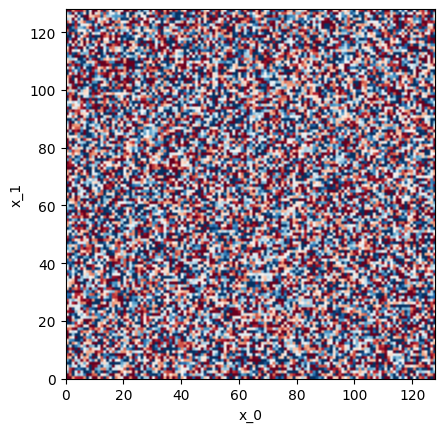

In [3]:
ex.viz.plot_state_2d(ic)

Let's instantiate a time stepper for the Kolmogorov flow.

(We use a 10 substeps of $\Delta \tau = 0.01$ for a total time step of $\Delta t = 0.1$ to ensure stability.)

In [4]:
stepper = ex.RepeatedStepper(
    ex.stepper.KolmogorovFlowVorticity(
        2,
        2 * jnp.pi,
        128,
        0.1 / 10,
        diffusivity=1e-2,
        order=4,
    ),
    10,
)

As you see, this is just an equinox Module.

In [5]:
stepper

RepeatedStepper(
  num_spatial_dims=2,
  domain_extent=6.283185307179586,
  num_points=128,
  num_channels=1,
  dt=0.1,
  dx=0.04908738521234052,
  stepper=KolmogorovFlowVorticity(
    num_spatial_dims=2,
    domain_extent=6.283185307179586,
    num_points=128,
    num_channels=1,
    dt=0.01,
    dx=0.04908738521234052,
    _integrator=ETDRK4(
      dt=0.01,
      _exp_term=c64[1,128,65],
      _nonlinear_fun=VorticityConvection2dKolmogorov(
        num_spatial_dims=2,
        num_points=128,
        dealiasing_mask=bool[1,128,65],
        convection_scale=1.0,
        derivative_operator=c64[2,128,65],
        inv_laplacian=c64[1,128,65],
        injection=f32[1,128,65]
      ),
      _half_exp_term=c64[1,128,65],
      _coef_1=f32[1,128,65],
      _coef_2=f32[1,128,65],
      _coef_3=f32[1,128,65],
      _coef_4=f32[1,128,65],
      _coef_5=f32[1,128,65],
      _coef_6=f32[1,128,65]
    ),
    diffusivity=0.01,
    convection_scale=1.0,
    drag=-0.1,
    injection_mode=4,
    injec

It produces a next state given a current state

In [6]:
after_ic = stepper(ic)

Not much changed

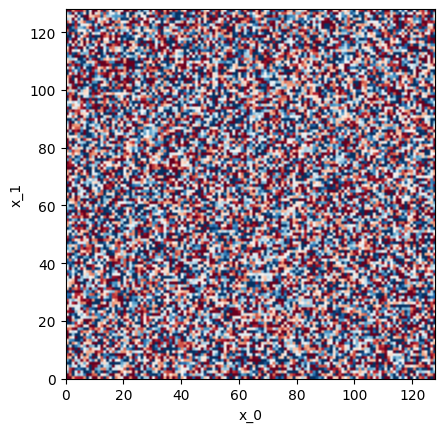

In [7]:
ex.viz.plot_state_2d(ic)

Let's do a couple more steps

In [8]:
further_state = ic

for _ in range(30):
    further_state = stepper(further_state)

Looks better: The flow is about to break up!

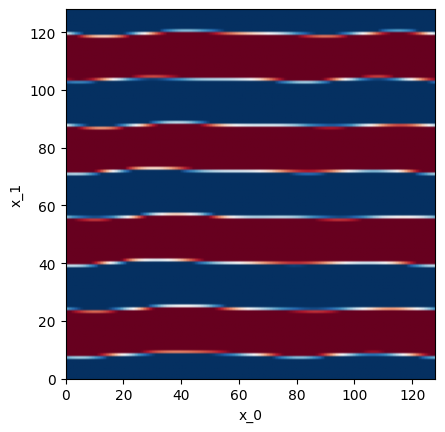

In [9]:
ex.viz.plot_state_2d(further_state)

However, it was quite slow. Let's JIT compile the stepper, and we can run further!

In [12]:
further_state_jit = ic

for _ in range(1000):
    further_state_jit = eqx.filter_jit(stepper)(further_state_jit)

Looks more like Kolmogorov flow now!

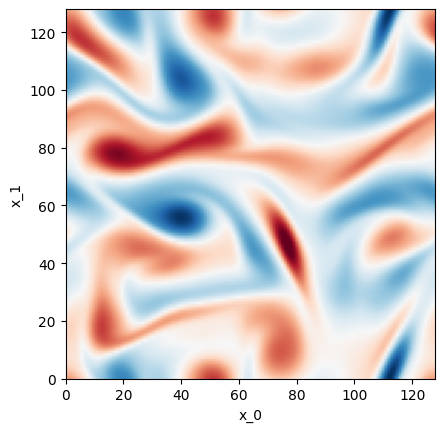

In [14]:
ex.viz.plot_state_2d(further_state_jit, vlim=(-10, 10))

But we can go even further if we push the for loop into the compiler (internally using `jax.lax.scan`)

In [15]:
further_state_repeated = ex.repeat(
    stepper,
    3000,
)(ic)

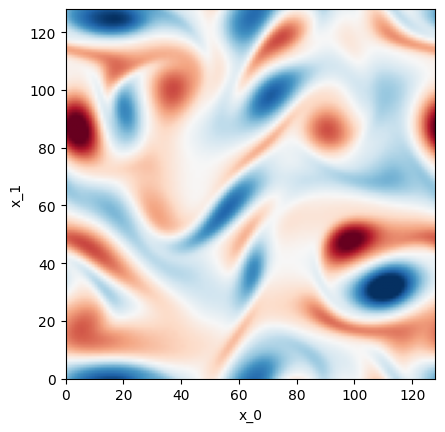

In [17]:
ex.viz.plot_state_2d(further_state_repeated, vlim=(-10, 10))

Now let's record a trajectory and animate it!

In [18]:
trj = ex.rollout(stepper, 50, include_init=True)(further_state_repeated)

In [20]:
ani = ex.viz.animate_state_2d(
    trj,
    vlim=(-10, 10),
)

Looks really cool, right?

In [ ]:
HTML(ani.to_jshtml())